In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving 청와대뉴스룸.txt to 청와대뉴스룸 (1).txt


핵심 키워드 Top 5


,명사,빈도수
0,국가,9
1,지능,8
2,전략,8
3,위원회,6
4,대한민국,6


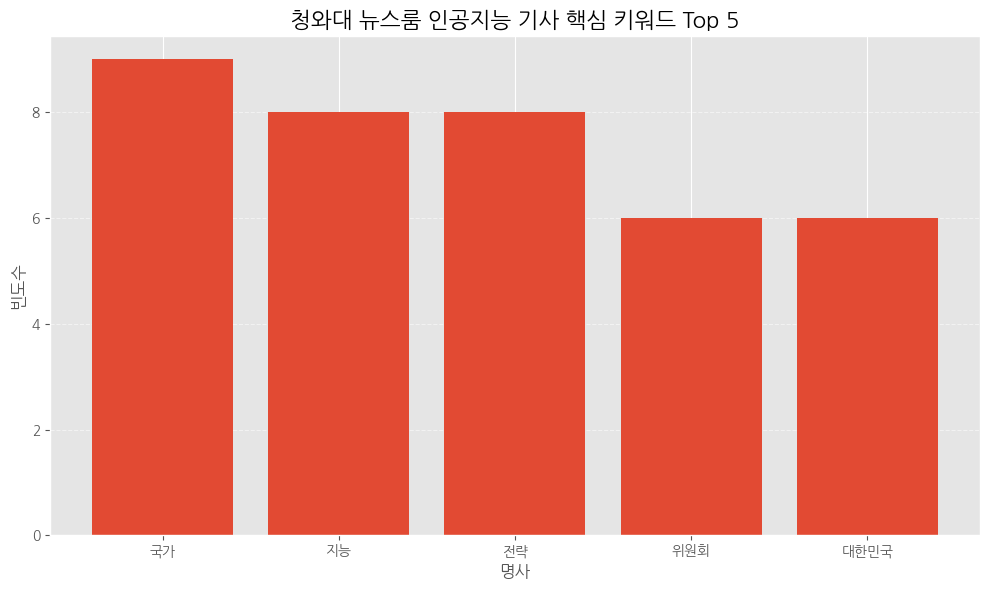

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# ============================================================
# 청와대 뉴스룸 기사 형태소 분석
# 핵심 키워드 Top 5
# ============================================================

!apt-get -qq install fonts-nanum
!pip -q install konlpy

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from konlpy.tag import Okt
from collections import Counter
from google.colab import files
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 파일 업로드
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# ============================================================
# 텍스트 읽기
# ============================================================

with open(
    file_name,
    'r',
    encoding='utf-8'
) as f:

    text = f.read()

# ============================================================
# 형태소 분석
# ============================================================

okt = Okt()

# 명사 추출
nouns = okt.nouns(text)

# 2글자 이상만 사용
nouns = [
    word
    for word in nouns
    if len(word) >= 2
]

# ============================================================
# 빈도 분석
# ============================================================

counter = Counter(nouns)

top5 = counter.most_common(5)

top5_df = pd.DataFrame(
    top5,
    columns=[
        '명사',
        '빈도수'
    ]
)

# ============================================================
# 결과 출력
# ============================================================

print("\n")
print("="*60)
print("핵심 키워드 Top 5")
print("="*60)

display(top5_df)

# ============================================================
# 막대 그래프
# ============================================================

plt.figure(
    figsize=(10,6),
    facecolor='white'
)

plt.bar(
    top5_df['명사'],
    top5_df['빈도수']
)

plt.title(
    '청와대 뉴스룸 인공지능 기사 핵심 키워드 Top 5',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    '명사',
    fontsize=12
)

plt.ylabel(
    '빈도수',
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

# ============================================================
# 엑셀 저장
# ============================================================

top5_df.to_excel(
    '청와대뉴스룸_키워드분석.xlsx',
    index=False
)

files.download(
    '청와대뉴스룸_키워드분석.xlsx'
)